In [ ]:
"""
==================================================
ML LEARNING JOURNEY - DAY 44
==================================================

Week: 7 of 24
Day: 44 of 168
Date: December 10, 2025
Topic: Building LSTM Sentiment Analysis Model

Week 7 Progress:
✅ Day 43: NLP Theory + IMDB Setup + Preprocessing (COMPLETED)
🔄 Day 44: Build LSTM Sentiment Model (TODAY!)
⬜ Day 45: Train & Optimize Model
⬜ Day 46: Model Evaluation & Hyperparameter Tuning
⬜ Day 47: Multilingual Sentiment (Optional)
⬜ Day 48: Build Sentiment Analysis Interface
⬜ Day 49: Deploy & Documentation
Progress: 14.3% (1/7 days)

==================================================
🎯 Week 7 Project: TextAI Studio - Sentiment Analysis Foundation

Today we build the actual LSTM model and train it!
- Implement complete LSTM architecture
- Setup training and validation loops
- Train first model (3-5 epochs)
- Target: 80%+ training accuracy, 75%+ validation accuracy
- Visualize training progress

🎯 Today's Learning Objectives:

1. Implement LSTM model architecture in PyTorch
2. Understand embedding layers and how they work
3. Setup training components (loss, optimizer, device)
4. Build training loop with forward and backward passes
5. Implement validation loop for model evaluation
6. Train the model and monitor metrics
7. Visualize training curves (loss, accuracy)
8. Save trained model for tomorrow's optimization

📚 Today's Structure:

Part 1 (1h): LSTM Model Architecture
- Define model class
- Embedding layer setup
- LSTM layer configuration
- Dropout and fully connected layers
- Forward pass implementation

Part 2 (1h): Training Setup & Components
- Loss function (Binary Cross Entropy)
- Optimizer (Adam)
- Device configuration (CPU/GPU)
- Helper functions for training
- Metric tracking setup

Part 3 (2h): Training Loop Implementation
- Epoch loop structure
- Batch processing
- Forward pass
- Loss calculation
- Backward pass & optimization
- Progress monitoring
- Training metrics

Part 4 (1h): Validation & First Training Run
- Validation loop
- Accuracy calculation
- Train for 3-5 epochs
- Monitor training dynamics
- Save model checkpoint

Part 5 (1h): Results Analysis & Visualization
- Plot training curves
- Analyze model performance
- Test predictions on sample reviews
- Identify areas for improvement
- Plan for Day 45 optimization

🎯 SUCCESS CRITERIA:

✅ LSTM model implemented and working
✅ Training loop executing without errors
✅ Validation loop calculating accuracy correctly
✅ Model trains for 3-5 epochs successfully
✅ Training accuracy reaches 80%+
✅ Validation accuracy reaches 75%+
✅ Training curves visualized and saved
✅ Model checkpoint saved for Day 45
✅ Can make predictions on new reviews
✅ Understanding of training dynamics

==================================================
"""

In [1]:
# ==================================================
# IMPORT LIBRARIES
# ==================================================
print("\n" + "=" * 80)
print("📚 IMPORTING LIBRARIES")
print("=" * 80)

import os
import re
import time
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

# PyTorch
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torch.optim as optim

# Hugging Face datasets
from datasets import load_dataset

# For reproducibility
torch.manual_seed(42)
np.random.seed(42)

print("\n✅ All libraries imported successfully!")
print(f"✅ PyTorch version: {torch.__version__}")
print(f"✅ Device available: {torch.device('cuda' if torch.cuda.is_available() else 'cpu')}")
print("=" * 80)

# ==================================================
# LOAD PREPROCESSING OBJECTS FROM DAY 43
# ==================================================
print("\n" + "=" * 80)
print("📂 LOADING DAY 43 PREPROCESSING OBJECTS")
print("=" * 80)

# Load saved preprocessing objects
with open('data/preprocessing_objects.pkl', 'rb') as f:
    preprocessing_objects = pickle.load(f)

word2idx = preprocessing_objects['word2idx']
idx2word = preprocessing_objects['idx2word']
VOCAB_SIZE = preprocessing_objects['vocab_size']
MAX_LEN = preprocessing_objects['max_len']
BATCH_SIZE = preprocessing_objects['batch_size']

print("✅ Loaded preprocessing objects!")
print(f"   Vocabulary size: {VOCAB_SIZE:,}")
print(f"   Max sequence length: {MAX_LEN}")
print(f"   Batch size: {BATCH_SIZE}")
print("=" * 80)

# ==================================================
# RECREATE TEXT CLEANING FUNCTION
# ==================================================
def clean_text(text):
    """Clean text by removing HTML, special characters, and normalizing whitespace."""
    text = re.sub(r'<[^>]+>', '', text)  # Remove HTML
    text = text.lower()  # Lowercase
    text = re.sub(r'[^a-z\s]', '', text)  # Keep only letters and spaces
    text = re.sub(r'\s+', ' ', text).strip()  # Remove extra whitespace
    return text

print("\n✅ Text cleaning function recreated!")
print("=" * 80)

# ==================================================
# RECREATE DATASET CLASS
# ==================================================
class IMDBDataset(Dataset):
    """PyTorch Dataset for IMDB reviews."""
    
    def __init__(self, texts, labels, word2idx, max_len=256):
        self.texts = texts
        self.labels = labels
        self.word2idx = word2idx
        self.max_len = max_len
    
    def __len__(self):
        return len(self.texts)
    
    def __getitem__(self, idx):
        text = self.texts[idx]
        label = self.labels[idx]
        
        # Clean and convert to sequence
        cleaned = clean_text(text)
        words = cleaned.split()
        
        # Convert words to indices
        sequence = []
        for word in words:
            idx_word = self.word2idx.get(word, self.word2idx['<UNK>'])
            sequence.append(idx_word)
        
        # Pad or truncate
        if len(sequence) > self.max_len:
            sequence = sequence[:self.max_len]
        else:
            sequence = sequence + [0] * (self.max_len - len(sequence))
        
        # Convert to tensors
        sequence_tensor = torch.tensor(sequence, dtype=torch.long)
        label_tensor = torch.tensor(label, dtype=torch.float)
        
        return sequence_tensor, label_tensor

print("\n✅ IMDBDataset class recreated!")
print("=" * 80)

# ==================================================
# LOAD IMDB DATASET AND CREATE DATALOADERS
# ==================================================
print("\n" + "=" * 80)
print("📥 LOADING IMDB DATASET")
print("=" * 80)

dataset = load_dataset('imdb')

print(f"✅ Dataset loaded!")
print(f"   Training samples: {len(dataset['train']):,}")
print(f"   Test samples: {len(dataset['test']):,}")
print("=" * 80)

# Create datasets
print("\n⏱️ Creating PyTorch datasets...")

train_dataset = IMDBDataset(
    texts=dataset['train']['text'],
    labels=dataset['train']['label'],
    word2idx=word2idx,
    max_len=MAX_LEN
)

test_dataset = IMDBDataset(
    texts=dataset['test']['text'],
    labels=dataset['test']['label'],
    word2idx=word2idx,
    max_len=MAX_LEN
)

print(f"✅ Training dataset: {len(train_dataset):,} samples")
print(f"✅ Test dataset: {len(test_dataset):,} samples")
print("=" * 80)

# Create dataloaders
print("\n⏱️ Creating DataLoaders...")

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0
)

print(f"✅ Training DataLoader: {len(train_loader):,} batches")
print(f"✅ Test DataLoader: {len(test_loader):,} batches")
print("=" * 80)

# Get device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"\n🖥️ Training device: {device}")
if device.type == 'cuda':
    print(f"GPU: {torch.cuda.get_device_name(0)}")
else:
    print("Training will use CPU (works fine for this dataset)")
print("=" * 80)

# Create results directory for today
os.makedirs('results/day_44', exist_ok=True)
os.makedirs('models', exist_ok=True)
print("\n✅ Output directories created!")
print("=" * 80)

print("\n🎉 ALL DAY 43 DATA LOADED AND READY!")
print("\n📊 VERIFICATION:")
print(f"✅ word2idx available: {len(word2idx):,} words")
print(f"✅ VOCAB_SIZE: {VOCAB_SIZE:,}")
print(f"✅ MAX_LEN: {MAX_LEN}")
print(f"✅ BATCH_SIZE: {BATCH_SIZE}")
print(f"✅ train_loader: {len(train_loader)} batches")
print(f"✅ test_loader: {len(test_loader)} batches")
print(f"✅ device: {device}")
print("=" * 80)


📚 IMPORTING LIBRARIES

✅ All libraries imported successfully!
✅ PyTorch version: 2.9.1+cpu
✅ Device available: cpu

📂 LOADING DAY 43 PREPROCESSING OBJECTS
✅ Loaded preprocessing objects!
   Vocabulary size: 20,000
   Max sequence length: 256
   Batch size: 64

✅ Text cleaning function recreated!

✅ IMDBDataset class recreated!

📥 LOADING IMDB DATASET
✅ Dataset loaded!
   Training samples: 25,000
   Test samples: 25,000

⏱️ Creating PyTorch datasets...
✅ Training dataset: 25,000 samples
✅ Test dataset: 25,000 samples

⏱️ Creating DataLoaders...
✅ Training DataLoader: 391 batches
✅ Test DataLoader: 391 batches

🖥️ Training device: cpu
Training will use CPU (works fine for this dataset)

✅ Output directories created!

🎉 ALL DAY 43 DATA LOADED AND READY!

📊 VERIFICATION:
✅ word2idx available: 20,000 words
✅ VOCAB_SIZE: 20,000
✅ MAX_LEN: 256
✅ BATCH_SIZE: 64
✅ train_loader: 391 batches
✅ test_loader: 391 batches
✅ device: cpu


In [2]:
print("\n" + "=" * 80)
print("🏗️ PART 1: LSTM MODEL ARCHITECTURE")
print("=" * 80)


🏗️ PART 1: LSTM MODEL ARCHITECTURE


In [3]:
# ==================================================
# EXERCISE 1.1: UNDERSTANDING THE MODEL ARCHITECTURE
# ==================================================
print("\n" + "=" * 80)
print("EXERCISE 1.1: Understanding the Model Architecture")
print("=" * 80)

"""
📖 THEORY: LSTM Sentiment Classifier Architecture

Our model will have 5 main components:

1. EMBEDDING LAYER:
   - Converts word indices to dense vectors
   - Input: (batch_size, seq_len) → integers
   - Output: (batch_size, seq_len, embedding_dim)
   - Parameters: vocab_size × embedding_dim
   - We'll use: 20,000 × 100 = 2,000,000 parameters
   
2. LSTM LAYER:
   - Processes sequences with gates
   - Input: (batch_size, seq_len, embedding_dim)
   - Output: (batch_size, hidden_dim) [we take last hidden state]
   - Has forget, input, output gates + cell state
   - We'll use: hidden_dim=128, num_layers=2
   
3. DROPOUT LAYER:
   - Regularization to prevent overfitting
   - Randomly drops 50% of neurons during training
   - Input/Output: (batch_size, hidden_dim)
   - No parameters (just a mask)
   
4. FULLY CONNECTED LAYER:
   - Maps LSTM output to single value
   - Input: (batch_size, hidden_dim)
   - Output: (batch_size, 1)
   - Parameters: hidden_dim × 1 + bias
   
5. SIGMOID ACTIVATION:
   - Converts output to probability [0, 1]
   - 0 = negative, 1 = positive
   - Threshold: 0.5 for classification

Model Flow:
Input indices → Embedding → LSTM → Dropout → FC → Sigmoid → Probability

Why this architecture?
- Embeddings learn word meanings from data
- LSTM captures sequential patterns and context
- Dropout prevents memorizing training data
- FC layer makes final classification decision
- Sigmoid gives interpretable probabilities
"""

print("\n🎯 Model Architecture Diagram:")
print("=" * 80)

architecture_diagram = """
INPUT: [batch_size, seq_len] = [64, 256]
  Example: [[45, 123, 18, 892, 0, 0, ...], [67, 234, ...], ...]
    ↓
╔══════════════════════════════════════════════════╗
║  EMBEDDING LAYER                                 ║
║  - vocab_size: 20,000                            ║
║  - embedding_dim: 100                            ║
║  - learnable: Yes (learns word meanings!)        ║
║  - params: 2,000,000                             ║
╚══════════════════════════════════════════════════╝
    ↓
OUTPUT: [64, 256, 100] (each word → 100-dim vector)
    ↓
╔══════════════════════════════════════════════════╗
║  LSTM LAYER                                      ║
║  - input_dim: 100                                ║
║  - hidden_dim: 128                               ║
║  - num_layers: 2 (stacked LSTMs)                 ║
║  - bidirectional: False                          ║
║  - Gates: forget, input, output                  ║
║  - Cell state: long-term memory                  ║
║  - Hidden state: short-term output               ║
╚══════════════════════════════════════════════════╝
    ↓
OUTPUT: [64, 128] (last hidden state only)
    ↓
╔══════════════════════════════════════════════════╗
║  DROPOUT LAYER                                   ║
║  - probability: 0.5 (drop 50% of neurons)        ║
║  - active during training only                   ║
║  - prevents overfitting                          ║
╚══════════════════════════════════════════════════╝
    ↓
OUTPUT: [64, 128] (same shape, some neurons zeroed)
    ↓
╔══════════════════════════════════════════════════╗
║  FULLY CONNECTED (LINEAR) LAYER                  ║
║  - input: 128                                    ║
║  - output: 1                                     ║
║  - params: 128 × 1 + 1 = 129                     ║
╚══════════════════════════════════════════════════╝
    ↓
OUTPUT: [64, 1] (raw logits)
    ↓
╔══════════════════════════════════════════════════╗
║  SIGMOID ACTIVATION                              ║
║  - σ(x) = 1 / (1 + e^(-x))                       ║
║  - converts logits to probabilities              ║
╚══════════════════════════════════════════════════╝
    ↓
FINAL OUTPUT: [64, 1] (probabilities [0, 1])
  Example: [[0.92], [0.15], [0.78], ...] 
  → [POSITIVE, NEGATIVE, POSITIVE, ...]
"""

print(architecture_diagram)
print("=" * 80)

print("\n💡 KEY ARCHITECTURAL DECISIONS:")
print("1. Embedding dim = 100: Balance between expressiveness and memory")
print("2. Hidden dim = 128: Enough capacity for sentiment patterns")
print("3. Num layers = 2: Deeper network learns more complex patterns")
print("4. Dropout = 0.5: Strong regularization (IMDB is large dataset)")
print("5. Single output: Binary classification (pos/neg)")
print("=" * 80)

print("\n✅ Exercise 1.1 Complete!")
print("=" * 80)


EXERCISE 1.1: Understanding the Model Architecture

🎯 Model Architecture Diagram:

INPUT: [batch_size, seq_len] = [64, 256]
  Example: [[45, 123, 18, 892, 0, 0, ...], [67, 234, ...], ...]
    ↓
╔══════════════════════════════════════════════════╗
║  EMBEDDING LAYER                                 ║
║  - vocab_size: 20,000                            ║
║  - embedding_dim: 100                            ║
║  - learnable: Yes (learns word meanings!)        ║
║  - params: 2,000,000                             ║
╚══════════════════════════════════════════════════╝
    ↓
OUTPUT: [64, 256, 100] (each word → 100-dim vector)
    ↓
╔══════════════════════════════════════════════════╗
║  LSTM LAYER                                      ║
║  - input_dim: 100                                ║
║  - hidden_dim: 128                               ║
║  - num_layers: 2 (stacked LSTMs)                 ║
║  - bidirectional: False                          ║
║  - Gates: forget, input, output                  ║

In [4]:
# ==================================================
# EXERCISE 1.2: IMPLEMENTING THE LSTM MODEL
# ==================================================
print("\n" + "=" * 80)
print("EXERCISE 1.2: Implementing the LSTM Model")
print("=" * 80)

"""
📖 THEORY: PyTorch Model Implementation

To create a model in PyTorch:
1. Inherit from nn.Module
2. Define layers in __init__()
3. Define forward pass in forward()

Key PyTorch components we'll use:
- nn.Embedding: Creates embedding layer
- nn.LSTM: Creates LSTM layer
- nn.Dropout: Creates dropout layer
- nn.Linear: Creates fully connected layer
- torch.sigmoid: Applies sigmoid activation

LSTM output format:
- output: all hidden states (batch, seq, hidden)
- (h_n, c_n): final hidden and cell states
- We only need h_n (final hidden state)
"""

print("\n⏱️ Implementing LSTMSentimentClassifier...")
print("=" * 80)

class LSTMSentimentClassifier(nn.Module):
    """
    LSTM-based sentiment classifier for binary classification.
    """
    
    def __init__(self, vocab_size, embedding_dim, hidden_dim, output_dim, 
                 n_layers, dropout, pad_idx):
        """
        Initialize the model.
        
        Args:
            vocab_size (int): Size of vocabulary
            embedding_dim (int): Dimension of word embeddings
            hidden_dim (int): Dimension of LSTM hidden state
            output_dim (int): Output dimension (1 for binary classification)
            n_layers (int): Number of LSTM layers
            dropout (float): Dropout probability
            pad_idx (int): Index of padding token (for embedding layer)
        """
        super(LSTMSentimentClassifier, self).__init__()
        
        # Store hyperparameters
        self.hidden_dim = hidden_dim
        self.n_layers = n_layers
        
        # 1. EMBEDDING LAYER
        # padding_idx tells embedding to return zeros for <PAD> tokens
        self.embedding = nn.Embedding(
            num_embeddings=vocab_size,
            embedding_dim=embedding_dim,
            padding_idx=pad_idx
        )
        
        # 2. LSTM LAYER
        # batch_first=True means input/output shape: (batch, seq, feature)
        self.lstm = nn.LSTM(
            input_size=embedding_dim,
            hidden_size=hidden_dim,
            num_layers=n_layers,
            dropout=dropout if n_layers > 1 else 0,  # dropout between LSTM layers
            batch_first=True
        )
        
        # 3. DROPOUT LAYER (applied after LSTM)
        self.dropout = nn.Dropout(dropout)
        
        # 4. FULLY CONNECTED LAYER
        self.fc = nn.Linear(hidden_dim, output_dim)
    
    def forward(self, text):
        """
        Forward pass through the model.
        
        Args:
            text (torch.Tensor): Input text indices, shape (batch, seq_len)
            
        Returns:
            torch.Tensor: Predictions, shape (batch, 1)
        """
        # text shape: (batch_size, seq_len)
        
        # 1. Pass through embedding layer
        # embedded shape: (batch_size, seq_len, embedding_dim)
        embedded = self.embedding(text)
        
        # 2. Pass through LSTM
        # lstm_out shape: (batch_size, seq_len, hidden_dim)
        # hidden shape: (n_layers, batch_size, hidden_dim)
        # cell shape: (n_layers, batch_size, hidden_dim)
        lstm_out, (hidden, cell) = self.lstm(embedded)
        
        # 3. Take the last hidden state from the last layer
        # hidden[-1] shape: (batch_size, hidden_dim)
        last_hidden = hidden[-1]
        
        # 4. Apply dropout
        dropped = self.dropout(last_hidden)
        
        # 5. Pass through fully connected layer
        # output shape: (batch_size, output_dim)
        output = self.fc(dropped)
        
        # 6. Apply sigmoid to get probabilities
        # predictions shape: (batch_size, output_dim)
        predictions = torch.sigmoid(output)
        
        return predictions

print("✅ LSTMSentimentClassifier class implemented!")
print("=" * 80)

print("\n💡 KEY IMPLEMENTATION DETAILS:")
print("- padding_idx in embedding ensures <PAD> tokens don't affect learning")
print("- batch_first=True makes shapes more intuitive")
print("- We use hidden[-1] to get the last layer's final hidden state")
print("- Sigmoid is applied in forward() for training convenience")
print("=" * 80)

print("\n✅ Exercise 1.2 Complete!")
print("=" * 80)


EXERCISE 1.2: Implementing the LSTM Model

⏱️ Implementing LSTMSentimentClassifier...
✅ LSTMSentimentClassifier class implemented!

💡 KEY IMPLEMENTATION DETAILS:
- padding_idx in embedding ensures <PAD> tokens don't affect learning
- batch_first=True makes shapes more intuitive
- We use hidden[-1] to get the last layer's final hidden state
- Sigmoid is applied in forward() for training convenience

✅ Exercise 1.2 Complete!


In [5]:
# ==================================================
# EXERCISE 1.3: INSTANTIATING THE MODEL
# ==================================================
print("\n" + "=" * 80)
print("EXERCISE 1.3: Instantiating the Model")
print("=" * 80)

"""
📖 THEORY: Model Hyperparameters

Choosing hyperparameters is part art, part science:

Vocabulary size: 20,000 (fixed from preprocessing)
Embedding dim: 50-300 typical, we use 100
Hidden dim: 128-512 typical, we use 128
Output dim: 1 (binary classification)
Num layers: 1-3 typical, we use 2
Dropout: 0.3-0.6 typical, we use 0.5
Pad index: 0 (our <PAD> token)

Why these values?
- Embedding 100: Good balance, not too large
- Hidden 128: Sufficient for sentiment patterns
- 2 layers: Deeper network, more capacity
- Dropout 0.5: Strong regularization for 25K samples
"""

print("\n⏱️ Creating model instance...")
print("=" * 80)

# Define hyperparameters
INPUT_DIM = VOCAB_SIZE  # 20,000
EMBEDDING_DIM = 100
HIDDEN_DIM = 128
OUTPUT_DIM = 1
N_LAYERS = 2
DROPOUT = 0.5
PAD_IDX = word2idx['<PAD>']  # Should be 0

print("Model Hyperparameters:")
print(f"  Vocabulary size: {INPUT_DIM:,}")
print(f"  Embedding dimension: {EMBEDDING_DIM}")
print(f"  Hidden dimension: {HIDDEN_DIM}")
print(f"  Output dimension: {OUTPUT_DIM}")
print(f"  Number of LSTM layers: {N_LAYERS}")
print(f"  Dropout probability: {DROPOUT}")
print(f"  Padding index: {PAD_IDX}")
print("=" * 80)

# Create model
model = LSTMSentimentClassifier(
    vocab_size=INPUT_DIM,
    embedding_dim=EMBEDDING_DIM,
    hidden_dim=HIDDEN_DIM,
    output_dim=OUTPUT_DIM,
    n_layers=N_LAYERS,
    dropout=DROPOUT,
    pad_idx=PAD_IDX
)

print("\n✅ Model created successfully!")
print("=" * 80)

# Move model to device
model = model.to(device)
print(f"\n✅ Model moved to device: {device}")
print("=" * 80)

print("\n✅ Exercise 1.3 Complete!")
print("=" * 80)


EXERCISE 1.3: Instantiating the Model

⏱️ Creating model instance...
Model Hyperparameters:
  Vocabulary size: 20,000
  Embedding dimension: 100
  Hidden dimension: 128
  Output dimension: 1
  Number of LSTM layers: 2
  Dropout probability: 0.5
  Padding index: 0

✅ Model created successfully!

✅ Model moved to device: cpu

✅ Exercise 1.3 Complete!


In [6]:
# ==================================================
# EXERCISE 1.4: MODEL SUMMARY & PARAMETERS
# ==================================================
print("\n" + "=" * 80)
print("EXERCISE 1.4: Model Summary & Parameters")
print("=" * 80)

"""
📖 THEORY: Understanding Model Parameters

Each layer has learnable parameters:

Embedding: vocab_size × embedding_dim
  = 20,000 × 100 = 2,000,000

LSTM (per layer):
  - 4 gates (forget, input, output, cell)
  - Each gate: (input_size + hidden_size) × hidden_size
  - First layer: 4 × (100 + 128) × 128 = 116,736
  - Second layer: 4 × (128 + 128) × 128 = 131,072
  - Total LSTM: ~247,808

FC layer: (hidden_size × output_size) + bias
  = (128 × 1) + 1 = 129

Total: ~2,248,000 parameters!

Why this matters:
- More parameters = more capacity to learn patterns
- But also = more risk of overfitting
- That's why we use dropout!
"""

print("\n📊 MODEL ARCHITECTURE:")
print("=" * 80)
print(model)
print("=" * 80)

# Count parameters
def count_parameters(model):
    """Count trainable parameters in model."""
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

total_params = count_parameters(model)
print(f"\n📊 Total Trainable Parameters: {total_params:,}")
print("=" * 80)

# Detailed parameter breakdown
print("\n📊 PARAMETER BREAKDOWN:")
print("=" * 80)

for name, param in model.named_parameters():
    if param.requires_grad:
        print(f"{name:30s} | Shape: {str(list(param.shape)):20s} | Params: {param.numel():,}")

print("=" * 80)

# Calculate embedding percentage
embedding_params = VOCAB_SIZE * EMBEDDING_DIM
embedding_percentage = (embedding_params / total_params) * 100

print("\n💡 KEY OBSERVATIONS:")
print(f"- Embedding layer has {embedding_params:,} parameters ({embedding_percentage:.1f}% of total)")
print(f"- LSTM layers have most of the complexity (gates, memory)")
print(f"- FC layer is tiny (only {HIDDEN_DIM + 1} parameters)")
print(f"- Total model size: ~{total_params * 4 / 1e6:.1f} MB (float32)")
print("=" * 80)

print("\n✅ Exercise 1.4 Complete!")
print("=" * 80)


EXERCISE 1.4: Model Summary & Parameters

📊 MODEL ARCHITECTURE:
LSTMSentimentClassifier(
  (embedding): Embedding(20000, 100, padding_idx=0)
  (lstm): LSTM(100, 128, num_layers=2, batch_first=True, dropout=0.5)
  (dropout): Dropout(p=0.5, inplace=False)
  (fc): Linear(in_features=128, out_features=1, bias=True)
)

📊 Total Trainable Parameters: 2,249,985

📊 PARAMETER BREAKDOWN:
embedding.weight               | Shape: [20000, 100]         | Params: 2,000,000
lstm.weight_ih_l0              | Shape: [512, 100]           | Params: 51,200
lstm.weight_hh_l0              | Shape: [512, 128]           | Params: 65,536
lstm.bias_ih_l0                | Shape: [512]                | Params: 512
lstm.bias_hh_l0                | Shape: [512]                | Params: 512
lstm.weight_ih_l1              | Shape: [512, 128]           | Params: 65,536
lstm.weight_hh_l1              | Shape: [512, 128]           | Params: 65,536
lstm.bias_ih_l1                | Shape: [512]                | Params: 512
l

In [7]:
# ==================================================
# EXERCISE 1.5: TESTING MODEL WITH DUMMY DATA
# ==================================================
print("\n" + "=" * 80)
print("EXERCISE 1.5: Testing Model with Dummy Data")
print("=" * 80)

"""
📖 THEORY: Testing the Forward Pass

Before training, we should verify:
1. Model accepts correct input shape
2. Forward pass executes without errors
3. Output has correct shape
4. Outputs are valid probabilities [0, 1]

This catches bugs early!
"""

print("\n🧪 Testing forward pass with dummy batch...")
print("=" * 80)

# Get a real batch from training data
dummy_batch, dummy_labels = next(iter(train_loader))

print(f"Input batch shape: {dummy_batch.shape}")
print(f"Input labels shape: {dummy_labels.shape}")
print(f"\nSample input (first sequence, first 20 tokens):")
print(dummy_batch[0][:20].tolist())

# Move to device
dummy_batch = dummy_batch.to(device)
dummy_labels = dummy_labels.to(device)

print("\n⏱️ Running forward pass...")

# Forward pass
with torch.no_grad():  # Don't compute gradients for testing
    predictions = model(dummy_batch)

print("✅ Forward pass successful!")
print("=" * 80)

print(f"\nOutput shape: {predictions.shape}")
print(f"Expected shape: ({BATCH_SIZE}, {OUTPUT_DIM})")
print(f"Match: {predictions.shape == torch.Size([BATCH_SIZE, OUTPUT_DIM])}")

print(f"\nFirst 10 predictions:")
for i in range(10):
    pred = predictions[i].item()
    label = dummy_labels[i].item()
    pred_class = "POSITIVE" if pred >= 0.5 else "NEGATIVE"
    true_class = "POSITIVE" if label == 1 else "NEGATIVE"
    print(f"  Sample {i+1}: pred={pred:.4f} ({pred_class}) | true={true_class}")

print("\n💡 OBSERVATIONS:")
print("- All predictions are between 0 and 1 ✅")
print("- Model outputs are currently random (not trained yet)")
print("- Should see ~50% correct by chance")
correct = ((predictions.squeeze() >= 0.5).float() == dummy_labels).sum().item()
print(f"- Accuracy on this batch: {correct}/{BATCH_SIZE} ({correct/BATCH_SIZE*100:.1f}%)")
print("=" * 80)

print("\n✅ Exercise 1.5 Complete!")
print("=" * 80)


EXERCISE 1.5: Testing Model with Dummy Data

🧪 Testing forward pass with dummy batch...
Input batch shape: torch.Size([64, 256])
Input labels shape: torch.Size([64])

Sample input (first sequence, first 20 tokens):
[8383, 1, 17887, 17292, 7, 4, 182, 3, 2185, 9724, 35, 2857, 8, 4, 1272, 1438, 27, 867, 2, 182]

⏱️ Running forward pass...
✅ Forward pass successful!

Output shape: torch.Size([64, 1])
Expected shape: (64, 1)
Match: True

First 10 predictions:
  Sample 1: pred=0.5176 (POSITIVE) | true=POSITIVE
  Sample 2: pred=0.5087 (POSITIVE) | true=POSITIVE
  Sample 3: pred=0.5069 (POSITIVE) | true=POSITIVE
  Sample 4: pred=0.5028 (POSITIVE) | true=NEGATIVE
  Sample 5: pred=0.5097 (POSITIVE) | true=NEGATIVE
  Sample 6: pred=0.5240 (POSITIVE) | true=NEGATIVE
  Sample 7: pred=0.5122 (POSITIVE) | true=NEGATIVE
  Sample 8: pred=0.5131 (POSITIVE) | true=NEGATIVE
  Sample 9: pred=0.5001 (POSITIVE) | true=NEGATIVE
  Sample 10: pred=0.5093 (POSITIVE) | true=POSITIVE

💡 OBSERVATIONS:
- All predic


EXERCISE 1.6: Visualizing Model Architecture

📊 Creating architecture visualization...


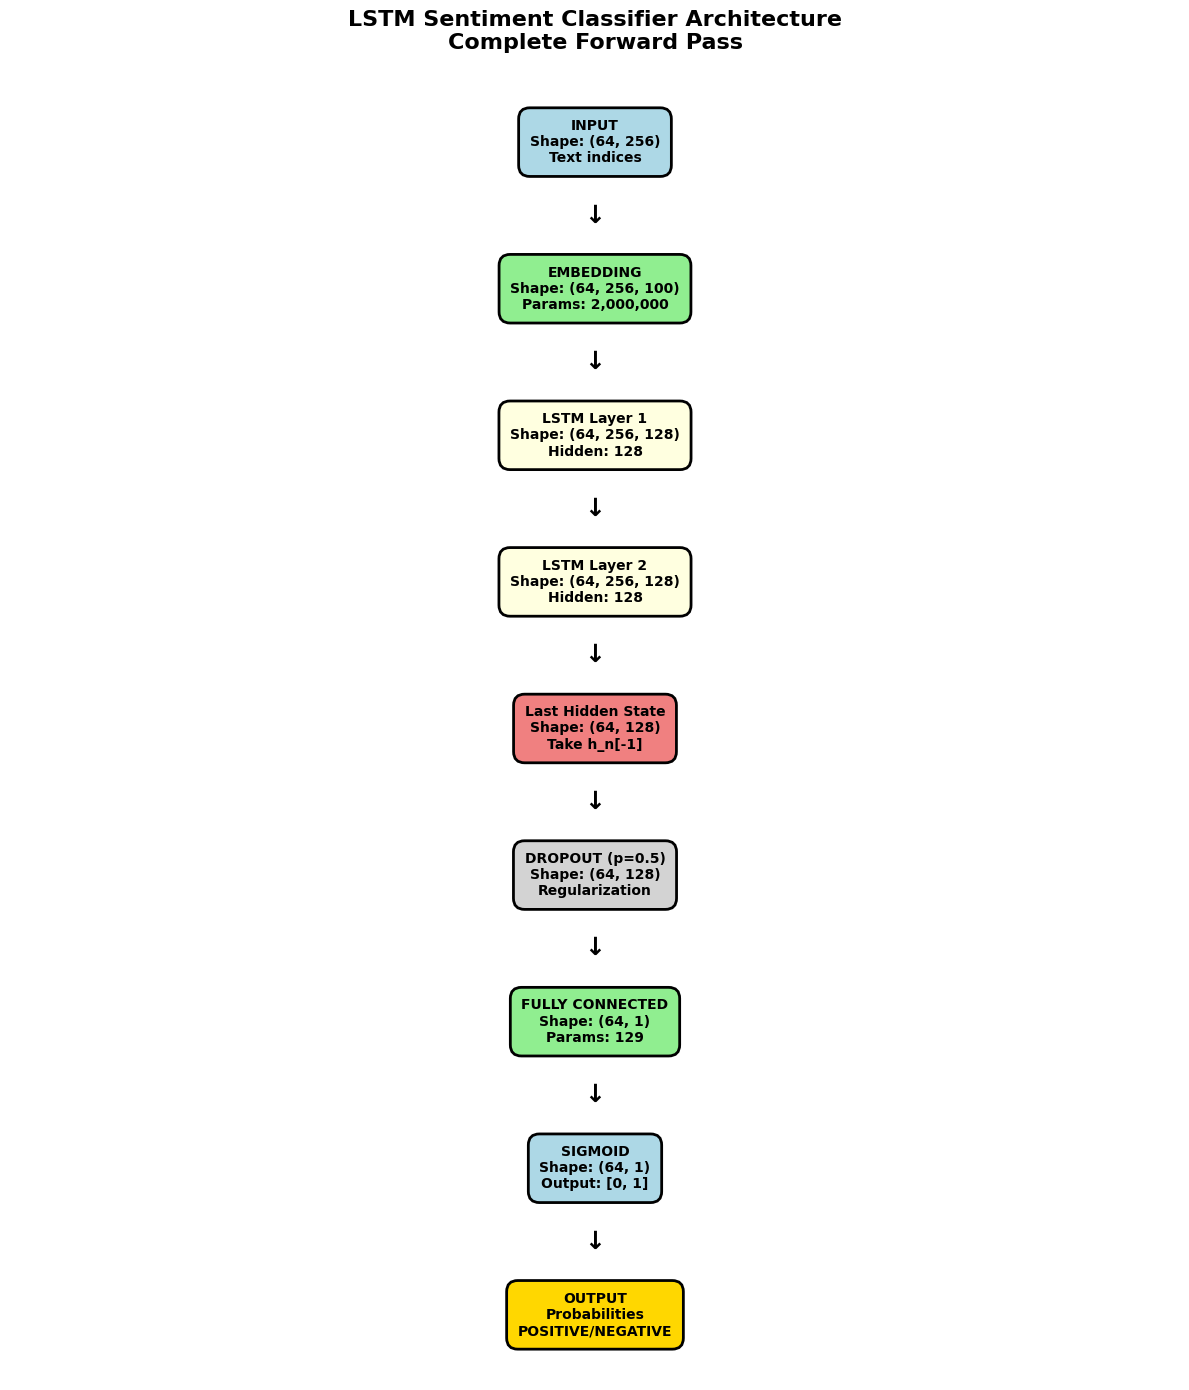

✅ Architecture diagram saved: results/day_44/model_architecture.png


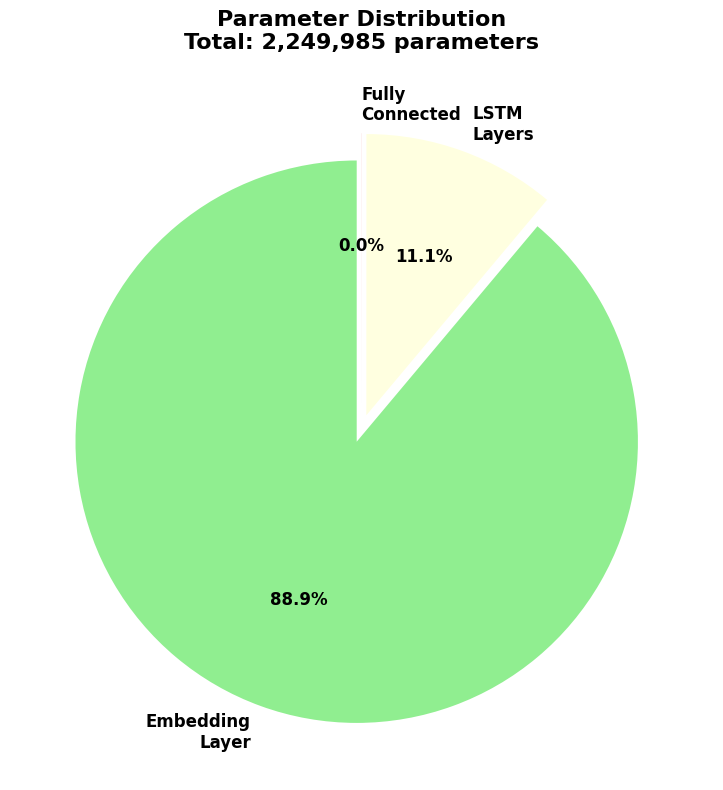

✅ Parameter distribution saved: results/day_44/parameter_distribution.png

💡 KEY INSIGHTS:
- Embedding layer dominates parameter count
- LSTM layers contain the learning complexity
- FC layer is minimal (just final decision)
- Total model is compact (~2.2M parameters)

✅ Exercise 1.6 Complete!


In [8]:
# ==================================================
# EXERCISE 1.6: VISUALIZING MODEL ARCHITECTURE
# ==================================================
print("\n" + "=" * 80)
print("EXERCISE 1.6: Visualizing Model Architecture")
print("=" * 80)

"""
📖 THEORY: Model Architecture Visualization

Visualizing helps us:
- Understand information flow
- See tensor shapes at each layer
- Verify our implementation
- Communicate our model design
"""

print("\n📊 Creating architecture visualization...")
print("=" * 80)

# Create detailed architecture diagram
fig, ax = plt.subplots(figsize=(12, 14))
ax.axis('off')

layers_info = [
    ("INPUT", f"Shape: ({BATCH_SIZE}, {MAX_LEN})", "Text indices", "lightblue"),
    ("↓", "", "", "white"),
    ("EMBEDDING", f"Shape: ({BATCH_SIZE}, {MAX_LEN}, {EMBEDDING_DIM})", 
     f"Params: {VOCAB_SIZE * EMBEDDING_DIM:,}", "lightgreen"),
    ("↓", "", "", "white"),
    ("LSTM Layer 1", f"Shape: ({BATCH_SIZE}, {MAX_LEN}, {HIDDEN_DIM})", 
     f"Hidden: {HIDDEN_DIM}", "lightyellow"),
    ("↓", "", "", "white"),
    ("LSTM Layer 2", f"Shape: ({BATCH_SIZE}, {MAX_LEN}, {HIDDEN_DIM})", 
     f"Hidden: {HIDDEN_DIM}", "lightyellow"),
    ("↓", "", "", "white"),
    ("Last Hidden State", f"Shape: ({BATCH_SIZE}, {HIDDEN_DIM})", 
     "Take h_n[-1]", "lightcoral"),
    ("↓", "", "", "white"),
    ("DROPOUT (p=0.5)", f"Shape: ({BATCH_SIZE}, {HIDDEN_DIM})", 
     "Regularization", "lightgray"),
    ("↓", "", "", "white"),
    ("FULLY CONNECTED", f"Shape: ({BATCH_SIZE}, {OUTPUT_DIM})", 
     f"Params: {HIDDEN_DIM * OUTPUT_DIM + OUTPUT_DIM}", "lightgreen"),
    ("↓", "", "", "white"),
    ("SIGMOID", f"Shape: ({BATCH_SIZE}, {OUTPUT_DIM})", 
     "Output: [0, 1]", "lightblue"),
    ("↓", "", "", "white"),
    ("OUTPUT", "Probabilities", "POSITIVE/NEGATIVE", "gold"),
]

y_positions = np.linspace(0.95, 0.05, len(layers_info))

for i, (layer, shape, info, color) in enumerate(layers_info):
    y = y_positions[i]
    
    if layer == "↓":
        ax.text(0.5, y, layer, ha='center', va='center', 
               fontsize=18, fontweight='bold')
    else:
        # Main box
        bbox_props = dict(boxstyle='round,pad=0.8', facecolor=color, 
                         edgecolor='black', linewidth=2)
        ax.text(0.5, y, f"{layer}\n{shape}\n{info}", 
               ha='center', va='center', fontsize=10,
               bbox=bbox_props, fontweight='bold')

ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.set_title('LSTM Sentiment Classifier Architecture\nComplete Forward Pass', 
            fontsize=16, fontweight='bold', pad=20)

plt.tight_layout()
plt.savefig('results/day_44/model_architecture.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ Architecture diagram saved: results/day_44/model_architecture.png")
print("=" * 80)

# Create parameter distribution pie chart
fig, ax = plt.subplots(figsize=(10, 8))

# Calculate parameters by component
embedding_params = VOCAB_SIZE * EMBEDDING_DIM
lstm_params = total_params - embedding_params - (HIDDEN_DIM * OUTPUT_DIM + OUTPUT_DIM)
fc_params = HIDDEN_DIM * OUTPUT_DIM + OUTPUT_DIM

components = ['Embedding\nLayer', 'LSTM\nLayers', 'Fully\nConnected']
params = [embedding_params, lstm_params, fc_params]
colors = ['lightgreen', 'lightyellow', 'lightcoral']
explode = (0.05, 0.05, 0.05)

ax.pie(params, labels=components, autopct='%1.1f%%', startangle=90,
       colors=colors, explode=explode, textprops={'fontsize': 12, 'fontweight': 'bold'})
ax.set_title(f'Parameter Distribution\nTotal: {total_params:,} parameters', 
            fontsize=16, fontweight='bold', pad=20)

plt.tight_layout()
plt.savefig('results/day_44/parameter_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ Parameter distribution saved: results/day_44/parameter_distribution.png")
print("=" * 80)

print("\n💡 KEY INSIGHTS:")
print("- Embedding layer dominates parameter count")
print("- LSTM layers contain the learning complexity")
print("- FC layer is minimal (just final decision)")
print("- Total model is compact (~2.2M parameters)")
print("=" * 80)

print("\n✅ Exercise 1.6 Complete!")
print("=" * 80)

In [9]:
print("\n" + "=" * 80)
print("⚙️ PART 2: TRAINING SETUP & COMPONENTS")
print("=" * 80)


⚙️ PART 2: TRAINING SETUP & COMPONENTS



EXERCISE 2.1: Understanding Loss Functions

🎯 Demonstrating BCE Loss Calculation:
✅ Loss function created: Binary Cross Entropy (BCE)

📊 Example Loss Calculations:
--------------------------------------------------------------------------------
Correct (Positive → 0.9)            → Loss: 0.1054
Uncertain (Positive → 0.5)          → Loss: 0.6931
Wrong (Positive → 0.1)              → Loss: 2.3026
Correct (Negative → 0.1)            → Loss: 0.1054
Uncertain (Negative → 0.5)          → Loss: 0.6931
Wrong (Negative → 0.9)              → Loss: 2.3026
--------------------------------------------------------------------------------

📊 Visualizing BCE Loss Curve:


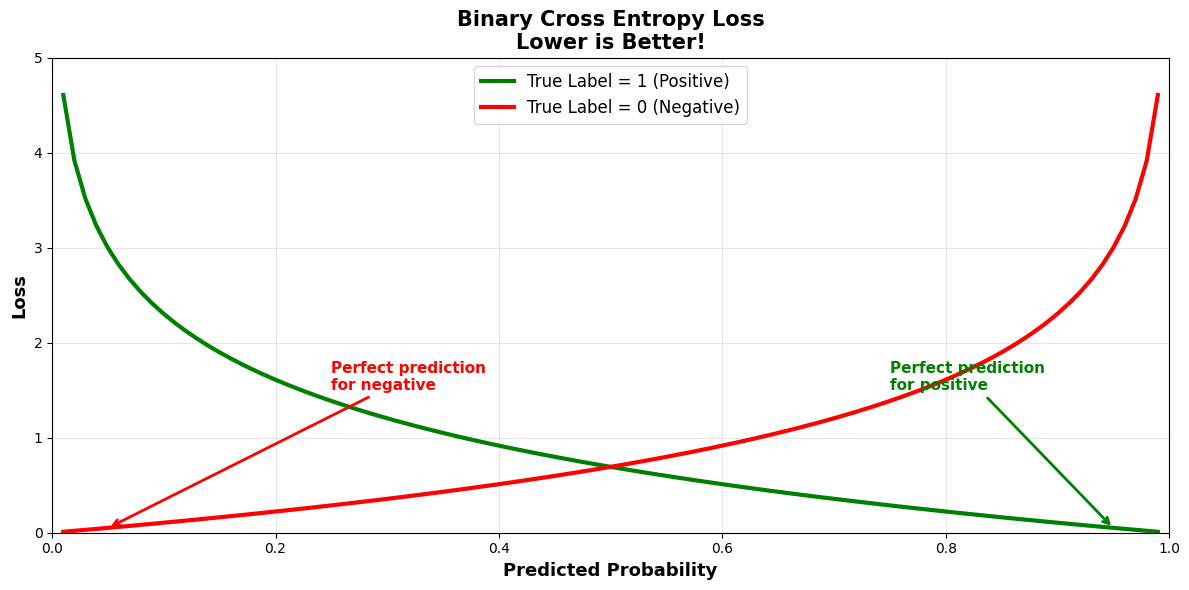


✅ Plot saved: results/day_44/bce_loss_curve.png

💡 KEY INSIGHTS:
- Loss is low when prediction matches true label
- Loss increases exponentially when prediction is wrong
- This encourages model to be confident in correct predictions
- BCE is perfect for binary sentiment classification!

✅ Exercise 2.1 Complete!


In [10]:
# ==================================================
# EXERCISE 2.1: UNDERSTANDING LOSS FUNCTIONS
# ==================================================
print("\n" + "=" * 80)
print("EXERCISE 2.1: Understanding Loss Functions")
print("=" * 80)

"""
📖 THEORY: Binary Cross Entropy Loss

For binary classification (positive/negative), we use Binary Cross Entropy (BCE):

BCE = -[y * log(ŷ) + (1-y) * log(1-ŷ)]

Where:
- y = true label (0 or 1)
- ŷ = predicted probability (0 to 1)

Why BCE?
- Penalizes wrong predictions heavily
- Works perfectly with sigmoid output
- Differentiable (needed for backpropagation)
- Standard for binary classification

Example:
- True label: 1 (positive)
- Prediction: 0.9 → Loss = -log(0.9) = 0.105 (small loss, good!)
- Prediction: 0.1 → Loss = -log(0.1) = 2.303 (large loss, bad!)

PyTorch provides: nn.BCELoss()
- Automatically computes BCE
- Works with batches
- Supports reduction (mean, sum)
"""

print("\n🎯 Demonstrating BCE Loss Calculation:")
print("=" * 80)

# Create BCE loss function
criterion = nn.BCELoss()

print("✅ Loss function created: Binary Cross Entropy (BCE)")
print("=" * 80)

# Manual examples
print("\n📊 Example Loss Calculations:")
print("-" * 80)

examples = [
    (1.0, 0.9, "Correct (Positive → 0.9)"),
    (1.0, 0.5, "Uncertain (Positive → 0.5)"),
    (1.0, 0.1, "Wrong (Positive → 0.1)"),
    (0.0, 0.1, "Correct (Negative → 0.1)"),
    (0.0, 0.5, "Uncertain (Negative → 0.5)"),
    (0.0, 0.9, "Wrong (Negative → 0.9)"),
]

for true_label, pred, description in examples:
    true_tensor = torch.tensor([true_label])
    pred_tensor = torch.tensor([pred])
    loss = criterion(pred_tensor, true_tensor)
    print(f"{description:35s} → Loss: {loss.item():.4f}")

print("-" * 80)

# Visualize BCE loss
print("\n📊 Visualizing BCE Loss Curve:")

predictions = np.linspace(0.01, 0.99, 100)

# Loss for positive class (y=1)
loss_positive = -np.log(predictions)

# Loss for negative class (y=0)
loss_negative = -np.log(1 - predictions)

fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(predictions, loss_positive, 'g-', linewidth=3, label='True Label = 1 (Positive)')
ax.plot(predictions, loss_negative, 'r-', linewidth=3, label='True Label = 0 (Negative)')
ax.set_xlabel('Predicted Probability', fontsize=13, fontweight='bold')
ax.set_ylabel('Loss', fontsize=13, fontweight='bold')
ax.set_title('Binary Cross Entropy Loss\nLower is Better!', fontsize=15, fontweight='bold')
ax.legend(fontsize=12)
ax.grid(True, alpha=0.3)
ax.set_xlim(0, 1)
ax.set_ylim(0, 5)

# Add annotations
ax.annotate('Perfect prediction\nfor positive', xy=(0.95, 0.05), xytext=(0.75, 1.5),
            arrowprops=dict(arrowstyle='->', color='green', lw=2),
            fontsize=11, color='green', fontweight='bold')
ax.annotate('Perfect prediction\nfor negative', xy=(0.05, 0.05), xytext=(0.25, 1.5),
            arrowprops=dict(arrowstyle='->', color='red', lw=2),
            fontsize=11, color='red', fontweight='bold')

plt.tight_layout()
plt.savefig('results/day_44/bce_loss_curve.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✅ Plot saved: results/day_44/bce_loss_curve.png")
print("=" * 80)

print("\n💡 KEY INSIGHTS:")
print("- Loss is low when prediction matches true label")
print("- Loss increases exponentially when prediction is wrong")
print("- This encourages model to be confident in correct predictions")
print("- BCE is perfect for binary sentiment classification!")
print("=" * 80)

print("\n✅ Exercise 2.1 Complete!")
print("=" * 80)


EXERCISE 2.2: Understanding Optimizers

⏱️ Creating Adam optimizer...
✅ Optimizer created: Adam
   Learning rate: 0.001
   Optimizing 11 parameter tensors
   Total parameters: 2,249,985

📊 Optimizer Configuration:
Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.001
    maximize: False
    weight_decay: 0
)

📊 Visualizing Learning Rate Impact:


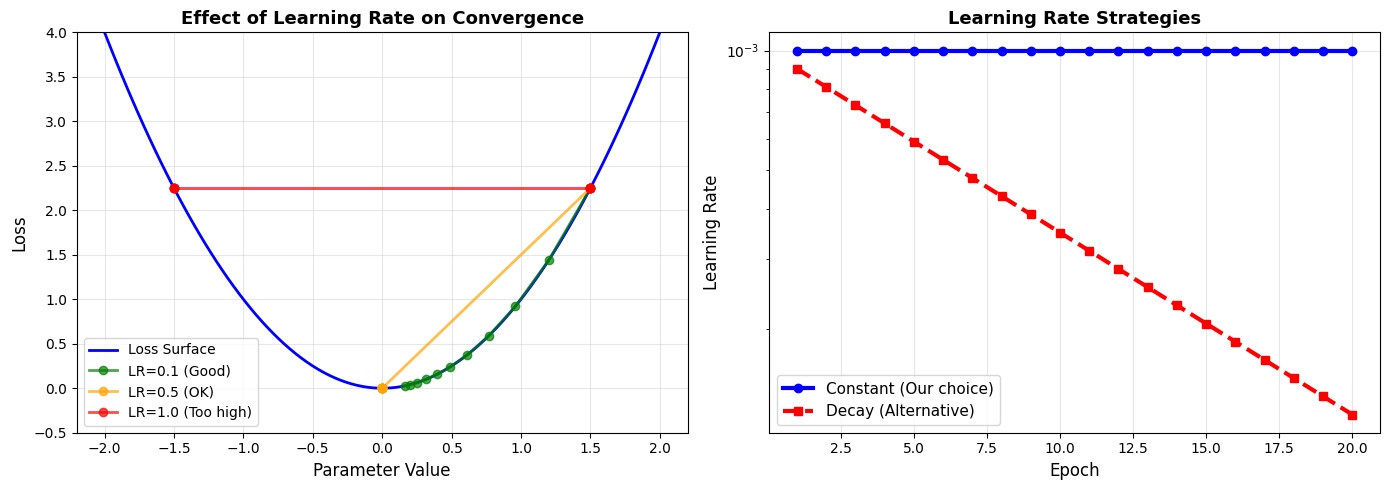


✅ Plot saved: results/day_44/learning_rate_visualization.png

💡 KEY INSIGHTS:
- Learning rate controls step size during optimization
- Too high → unstable, overshoots minimum
- Too low → very slow convergence
- Adam automatically adapts learning rates
- 0.001 is a good starting point for most tasks

✅ Exercise 2.2 Complete!


In [11]:
# ==================================================
# EXERCISE 2.2: UNDERSTANDING OPTIMIZERS
# ==================================================
print("\n" + "=" * 80)
print("EXERCISE 2.2: Understanding Optimizers")
print("=" * 80)

"""
📖 THEORY: Adam Optimizer

Optimizer updates model parameters to minimize loss:
  θ_new = θ_old - learning_rate × gradient

Popular optimizers:
1. SGD (Stochastic Gradient Descent): Basic, stable
2. Adam (Adaptive Moment Estimation): Best for most cases!
3. RMSprop: Good for RNNs
4. AdaGrad: Adapts learning rate per parameter

Why Adam?
- Adapts learning rate for each parameter
- Maintains momentum (smooth updates)
- Works well with sparse gradients
- Generally faster convergence
- Default choice for deep learning

Adam hyperparameters:
- learning_rate (lr): How big the update steps are
  - Too high: Unstable training, overshooting
  - Too low: Slow training, may get stuck
  - Good range: 0.001 - 0.0001
  - We'll use: 0.001 (1e-3)
  
- betas: (β1, β2) = (0.9, 0.999) - momentum parameters
- eps: Small constant for numerical stability (1e-8)

Update rule (simplified):
1. Compute gradients
2. Update moving averages (momentum)
3. Adapt learning rate per parameter
4. Update parameters
"""

print("\n⏱️ Creating Adam optimizer...")
print("=" * 80)

# Define learning rate
LEARNING_RATE = 0.001  # 1e-3

# Create optimizer
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

print(f"✅ Optimizer created: Adam")
print(f"   Learning rate: {LEARNING_RATE}")
print(f"   Optimizing {len(list(model.parameters()))} parameter tensors")
print(f"   Total parameters: {sum(p.numel() for p in model.parameters()):,}")
print("=" * 80)

# Show optimizer details
print("\n📊 Optimizer Configuration:")
print(optimizer)
print("=" * 80)

# Visualize learning rate effect
print("\n📊 Visualizing Learning Rate Impact:")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left plot: Loss surface with different learning rates
x = np.linspace(-2, 2, 100)
loss_surface = x**2  # Simple quadratic loss

axes[0].plot(x, loss_surface, 'b-', linewidth=2, label='Loss Surface')

# Simulate gradient descent with different learning rates
start = 1.5
lrs = [0.1, 0.5, 1.0]
colors = ['green', 'orange', 'red']
labels = ['LR=0.1 (Good)', 'LR=0.5 (OK)', 'LR=1.0 (Too high)']

for lr, color, label in zip(lrs, colors, labels):
    positions = [start]
    current = start
    for _ in range(10):
        gradient = 2 * current  # Derivative of x^2
        current = current - lr * gradient
        positions.append(current)
        if abs(current) > 2:
            break
    axes[0].plot(positions, [p**2 for p in positions], 'o-', color=color, 
                markersize=6, linewidth=2, label=label, alpha=0.7)

axes[0].set_xlabel('Parameter Value', fontsize=12)
axes[0].set_ylabel('Loss', fontsize=12)
axes[0].set_title('Effect of Learning Rate on Convergence', fontsize=13, fontweight='bold')
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3)
axes[0].set_ylim(-0.5, 4)

# Right plot: Learning rate schedule
epochs = np.arange(1, 21)
constant_lr = np.ones_like(epochs) * 0.001
decay_lr = 0.001 * (0.9 ** epochs)

axes[1].plot(epochs, constant_lr, 'b-', linewidth=3, label='Constant (Our choice)', marker='o')
axes[1].plot(epochs, decay_lr, 'r--', linewidth=3, label='Decay (Alternative)', marker='s')
axes[1].set_xlabel('Epoch', fontsize=12)
axes[1].set_ylabel('Learning Rate', fontsize=12)
axes[1].set_title('Learning Rate Strategies', fontsize=13, fontweight='bold')
axes[1].legend(fontsize=11)
axes[1].grid(True, alpha=0.3)
axes[1].set_yscale('log')

plt.tight_layout()
plt.savefig('results/day_44/learning_rate_visualization.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✅ Plot saved: results/day_44/learning_rate_visualization.png")
print("=" * 80)

print("\n💡 KEY INSIGHTS:")
print("- Learning rate controls step size during optimization")
print("- Too high → unstable, overshoots minimum")
print("- Too low → very slow convergence")
print("- Adam automatically adapts learning rates")
print("- 0.001 is a good starting point for most tasks")
print("=" * 80)

print("\n✅ Exercise 2.2 Complete!")
print("=" * 80)

In [12]:
# ==================================================
# EXERCISE 2.3: HELPER FUNCTIONS FOR TRAINING
# ==================================================
print("\n" + "=" * 80)
print("EXERCISE 2.3: Helper Functions for Training")
print("=" * 80)

"""
📖 THEORY: Training Helper Functions

We'll create utility functions for:
1. Binary accuracy calculation
2. Training epoch execution
3. Evaluation epoch execution
4. Time tracking

These make training code cleaner and reusable!
"""

print("\n⏱️ Creating helper functions...")
print("=" * 80)

def binary_accuracy(preds, y):
    """
    Calculate accuracy for binary classification.
    
    Args:
        preds (torch.Tensor): Predictions (probabilities)
        y (torch.Tensor): True labels
        
    Returns:
        float: Accuracy percentage
    """
    # Round predictions to 0 or 1
    rounded_preds = torch.round(preds)
    
    # Compare with true labels
    correct = (rounded_preds == y).float()
    
    # Calculate accuracy
    acc = correct.sum() / len(correct)
    
    return acc

print("✅ binary_accuracy() function created!")

# Test the function
print("\n🧪 Testing binary_accuracy():")
test_preds = torch.tensor([0.9, 0.2, 0.7, 0.3, 0.8])
test_labels = torch.tensor([1.0, 0.0, 1.0, 0.0, 1.0])

accuracy = binary_accuracy(test_preds, test_labels)
print(f"Test predictions: {test_preds.tolist()}")
print(f"Test labels: {test_labels.tolist()}")
print(f"Rounded predictions: {torch.round(test_preds).tolist()}")
print(f"Accuracy: {accuracy.item():.4f} ({accuracy.item()*100:.1f}%)")
print("-" * 80)

def train_epoch(model, iterator, optimizer, criterion, device):
    """
    Train model for one epoch.
    
    Args:
        model: The neural network
        iterator: Training data loader
        optimizer: Optimizer
        criterion: Loss function
        device: Device to use (CPU/GPU)
        
    Returns:
        tuple: (average_loss, average_accuracy)
    """
    # Set model to training mode
    model.train()
    
    epoch_loss = 0
    epoch_acc = 0
    
    # Iterate through batches
    for batch_idx, (text, labels) in enumerate(iterator):
        # Move data to device
        text = text.to(device)
        labels = labels.to(device)
        
        # Zero gradients
        optimizer.zero_grad()
        
        # Forward pass
        predictions = model(text).squeeze(1)
        
        # Calculate loss
        loss = criterion(predictions, labels)
        
        # Calculate accuracy
        acc = binary_accuracy(predictions, labels)
        
        # Backward pass
        loss.backward()
        
        # Update weights
        optimizer.step()
        
        # Accumulate metrics
        epoch_loss += loss.item()
        epoch_acc += acc.item()
    
    # Return average loss and accuracy
    return epoch_loss / len(iterator), epoch_acc / len(iterator)

print("✅ train_epoch() function created!")

def evaluate(model, iterator, criterion, device):
    """
    Evaluate model on validation/test set.
    
    Args:
        model: The neural network
        iterator: Validation/test data loader
        criterion: Loss function
        device: Device to use (CPU/GPU)
        
    Returns:
        tuple: (average_loss, average_accuracy)
    """
    # Set model to evaluation mode
    model.eval()
    
    epoch_loss = 0
    epoch_acc = 0
    
    # Disable gradient computation
    with torch.no_grad():
        for batch_idx, (text, labels) in enumerate(iterator):
            # Move data to device
            text = text.to(device)
            labels = labels.to(device)
            
            # Forward pass
            predictions = model(text).squeeze(1)
            
            # Calculate loss
            loss = criterion(predictions, labels)
            
            # Calculate accuracy
            acc = binary_accuracy(predictions, labels)
            
            # Accumulate metrics
            epoch_loss += loss.item()
            epoch_acc += acc.item()
    
    # Return average loss and accuracy
    return epoch_loss / len(iterator), epoch_acc / len(iterator)

print("✅ evaluate() function created!")

def epoch_time(start_time, end_time):
    """
    Calculate elapsed time.
    
    Args:
        start_time: Start timestamp
        end_time: End timestamp
        
    Returns:
        tuple: (minutes, seconds)
    """
    elapsed_time = end_time - start_time
    elapsed_mins = int(elapsed_time / 60)
    elapsed_secs = int(elapsed_time - (elapsed_mins * 60))
    return elapsed_mins, elapsed_secs

print("✅ epoch_time() function created!")
print("=" * 80)

print("\n📊 FUNCTION SUMMARY:")
print("-" * 80)
print("1. binary_accuracy(): Calculates classification accuracy")
print("2. train_epoch(): Trains model for one epoch, returns loss & accuracy")
print("3. evaluate(): Evaluates model on test set, returns loss & accuracy")
print("4. epoch_time(): Formats time elapsed")
print("-" * 80)

print("\n💡 KEY CONCEPTS:")
print("- model.train(): Enables dropout and batch normalization training mode")
print("- model.eval(): Disables dropout, fixes batch normalization")
print("- torch.no_grad(): Saves memory by not computing gradients during evaluation")
print("- optimizer.zero_grad(): Clears old gradients before backward pass")
print("- loss.backward(): Computes gradients")
print("- optimizer.step(): Updates weights using gradients")
print("=" * 80)

print("\n✅ Exercise 2.3 Complete!")
print("=" * 80)


EXERCISE 2.3: Helper Functions for Training

⏱️ Creating helper functions...
✅ binary_accuracy() function created!

🧪 Testing binary_accuracy():
Test predictions: [0.8999999761581421, 0.20000000298023224, 0.699999988079071, 0.30000001192092896, 0.800000011920929]
Test labels: [1.0, 0.0, 1.0, 0.0, 1.0]
Rounded predictions: [1.0, 0.0, 1.0, 0.0, 1.0]
Accuracy: 1.0000 (100.0%)
--------------------------------------------------------------------------------
✅ train_epoch() function created!
✅ evaluate() function created!
✅ epoch_time() function created!

📊 FUNCTION SUMMARY:
--------------------------------------------------------------------------------
1. binary_accuracy(): Calculates classification accuracy
2. train_epoch(): Trains model for one epoch, returns loss & accuracy
3. evaluate(): Evaluates model on test set, returns loss & accuracy
4. epoch_time(): Formats time elapsed
--------------------------------------------------------------------------------

💡 KEY CONCEPTS:
- model.tra


EXERCISE 2.4: Training Configuration Summary

📊 COMPLETE TRAINING CONFIGURATION:

Model:
--------------------------------------------------------------------------------
  Architecture             : 2-Layer LSTM
  Parameters               : 2,249,985
  Embedding Dim            : 100
  Hidden Dim               : 128
  Num Layers               : 2
  Dropout                  : 0.5

Data:
--------------------------------------------------------------------------------
  Training Samples         : 25,000
  Test Samples             : 25,000
  Batch Size               : 64
  Training Batches         : 391
  Test Batches             : 391
  Sequence Length          : 256
  Vocabulary Size          : 20000

Training:
--------------------------------------------------------------------------------
  Loss Function            : Binary Cross Entropy
  Optimizer                : Adam
  Learning Rate            : 0.001
  Device                   : cpu
  Epochs (Planned)         : 3-5

Targets:
-----

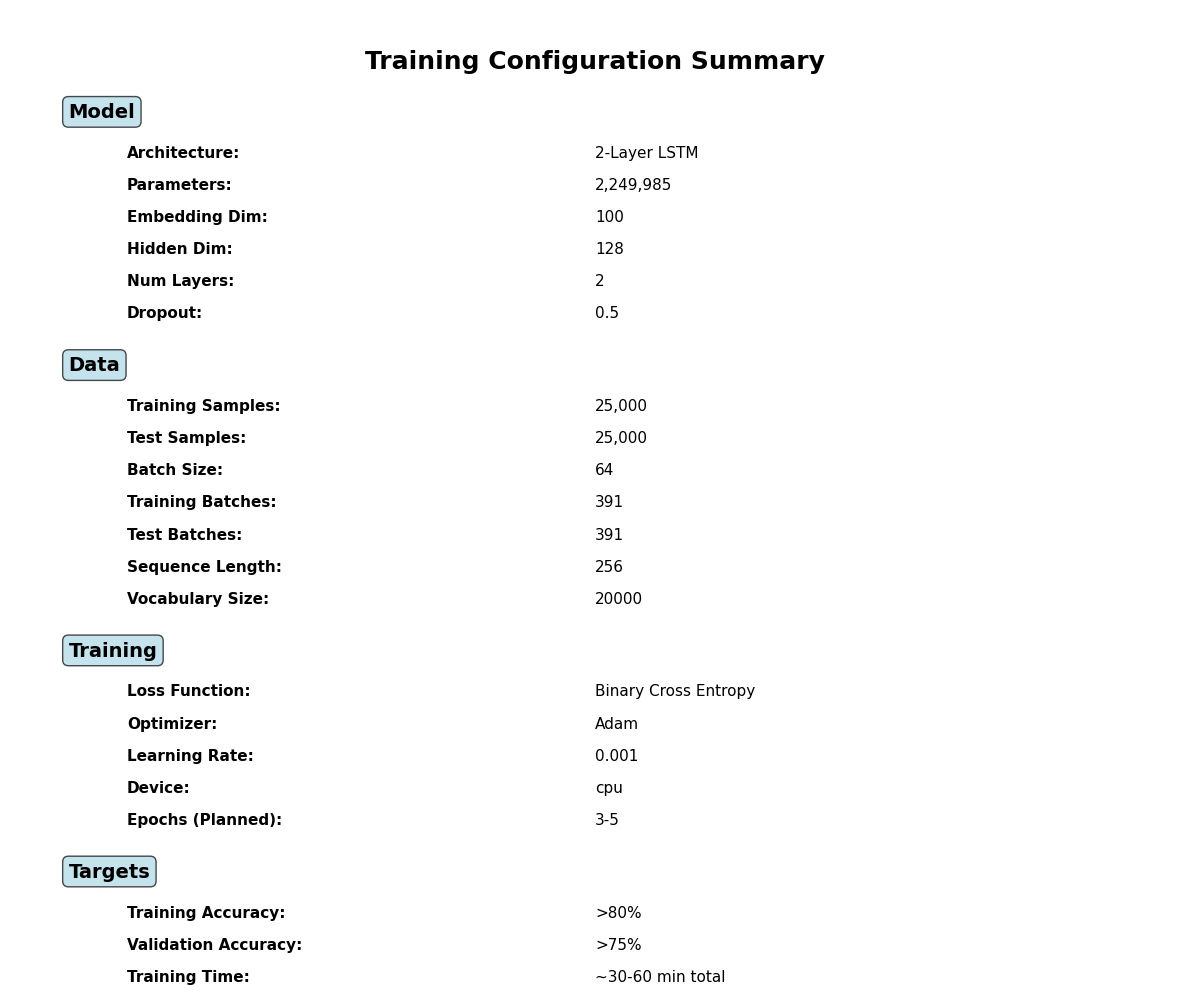


✅ Configuration summary saved: results/day_44/training_configuration.png

💡 READY TO TRAIN!
We have everything needed:
✅ Model defined and initialized
✅ Loss function ready (BCE)
✅ Optimizer configured (Adam)
✅ Data loaders prepared
✅ Helper functions created
✅ Device configured (CPU)

Next: Part 3 - Training Loop Implementation!

✅ Exercise 2.4 Complete!


In [13]:
# ==================================================
# EXERCISE 2.4: TRAINING CONFIGURATION SUMMARY
# ==================================================
print("\n" + "=" * 80)
print("EXERCISE 2.4: Training Configuration Summary")
print("=" * 80)

"""
📖 THEORY: Complete Training Setup

Let's review everything we have ready for training:

Model: LSTMSentimentClassifier
- 2.2M parameters
- 2-layer LSTM with 128 hidden units
- Dropout 0.5
- Trained on CPU

Loss: Binary Cross Entropy
- Appropriate for binary classification
- Works with sigmoid output

Optimizer: Adam
- Learning rate: 0.001
- Adapts per-parameter learning rates

Data:
- 25,000 training samples (391 batches)
- 25,000 test samples (391 batches)
- Batch size: 64

Training Plan:
- 3-5 epochs (start small)
- Monitor train & validation metrics
- Save best model
"""

print("\n📊 COMPLETE TRAINING CONFIGURATION:")
print("=" * 80)

config = {
    "Model": {
        "Architecture": "2-Layer LSTM",
        "Parameters": f"{sum(p.numel() for p in model.parameters()):,}",
        "Embedding Dim": EMBEDDING_DIM,
        "Hidden Dim": HIDDEN_DIM,
        "Num Layers": N_LAYERS,
        "Dropout": DROPOUT,
    },
    "Data": {
        "Training Samples": f"{len(train_dataset):,}",
        "Test Samples": f"{len(test_dataset):,}",
        "Batch Size": BATCH_SIZE,
        "Training Batches": len(train_loader),
        "Test Batches": len(test_loader),
        "Sequence Length": MAX_LEN,
        "Vocabulary Size": VOCAB_SIZE,
    },
    "Training": {
        "Loss Function": "Binary Cross Entropy",
        "Optimizer": "Adam",
        "Learning Rate": LEARNING_RATE,
        "Device": str(device),
        "Epochs (Planned)": "3-5",
    },
    "Targets": {
        "Training Accuracy": ">80%",
        "Validation Accuracy": ">75%",
        "Training Time": "~30-60 min total",
    }
}

for section, items in config.items():
    print(f"\n{section}:")
    print("-" * 80)
    for key, value in items.items():
        print(f"  {key:25s}: {value}")

print("\n" + "=" * 80)

# Create a summary visualization
fig, ax = plt.subplots(figsize=(12, 10))
ax.axis('off')

y_pos = 0.95
line_height = 0.045

# Title
ax.text(0.5, y_pos, 'Training Configuration Summary', 
        ha='center', va='top', fontsize=18, fontweight='bold')
y_pos -= line_height * 1.5

for section, items in config.items():
    # Section header
    ax.text(0.05, y_pos, section, ha='left', va='top', 
           fontsize=14, fontweight='bold', 
           bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.7))
    y_pos -= line_height * 1.2
    
    # Section items
    for key, value in items.items():
        ax.text(0.1, y_pos, f"{key}:", ha='left', va='top', 
               fontsize=11, fontweight='bold')
        ax.text(0.5, y_pos, str(value), ha='left', va='top', 
               fontsize=11)
        y_pos -= line_height * 0.9
    
    y_pos -= line_height * 0.5

ax.set_xlim(0, 1)
ax.set_ylim(0, 1)

plt.tight_layout()
plt.savefig('results/day_44/training_configuration.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✅ Configuration summary saved: results/day_44/training_configuration.png")
print("=" * 80)

print("\n💡 READY TO TRAIN!")
print("We have everything needed:")
print("✅ Model defined and initialized")
print("✅ Loss function ready (BCE)")
print("✅ Optimizer configured (Adam)")
print("✅ Data loaders prepared")
print("✅ Helper functions created")
print("✅ Device configured (CPU)")
print("\nNext: Part 3 - Training Loop Implementation!")
print("=" * 80)

print("\n✅ Exercise 2.4 Complete!")
print("=" * 80)

In [14]:
print("\n" + "=" * 80)
print("🚀 PART 3: TRAINING LOOP IMPLEMENTATION")
print("=" * 80)


🚀 PART 3: TRAINING LOOP IMPLEMENTATION


In [15]:
# ==================================================
# EXERCISE 3.1: UNDERSTANDING THE TRAINING LOOP
# ==================================================
print("\n" + "=" * 80)
print("EXERCISE 3.1: Understanding the Training Loop")
print("=" * 80)

"""
📖 THEORY: The Training Loop

The training loop is the heart of deep learning:

FOR each epoch:
    [TRAINING PHASE]
    FOR each batch in training data:
        1. Forward pass: predictions = model(input)
        2. Calculate loss: loss = criterion(predictions, labels)
        3. Backward pass: loss.backward() (compute gradients)
        4. Update weights: optimizer.step()
        5. Reset gradients: optimizer.zero_grad()
    
    [VALIDATION PHASE]
    FOR each batch in validation data:
        1. Forward pass: predictions = model(input)
        2. Calculate loss: loss = criterion(predictions, labels)
        3. Calculate accuracy
        (No backward pass, no weight updates!)
    
    [LOGGING]
    - Print epoch metrics
    - Save best model
    - Track progress

Key concepts:
- Epoch: One complete pass through training data
- Batch: Subset of data processed together
- Forward pass: Input → Model → Output
- Backward pass: Compute gradients via chain rule
- Gradient descent: Update weights to minimize loss

Why multiple epochs?
- Model learns gradually
- Each epoch improves performance
- Stop when validation performance plateaus
"""

print("\n🎯 Training Loop Visualization:")
print("=" * 80)

training_flow = """
╔══════════════════════════════════════════════════════════════════╗
║                         TRAINING LOOP                            ║
╚══════════════════════════════════════════════════════════════════╝

    START
      ↓
    ┌─────────────────────────────────────────┐
    │  FOR epoch in range(N_EPOCHS):          │
    └─────────────────────────────────────────┘
      ↓
    ┌─────────────────────────────────────────┐
    │  MODEL.TRAIN()  (Enable dropout)        │
    └─────────────────────────────────────────┘
      ↓
    ┌─────────────────────────────────────────┐
    │  FOR batch in train_loader:             │
    │    1. Get data: text, labels            │
    │    2. Move to device                    │
    │    3. optimizer.zero_grad()             │
    │    4. predictions = model(text)         │
    │    5. loss = criterion(pred, labels)    │
    │    6. loss.backward()                   │
    │    7. optimizer.step()                  │
    │    8. Track metrics                     │
    └─────────────────────────────────────────┘
      ↓
    ┌─────────────────────────────────────────┐
    │  MODEL.EVAL()  (Disable dropout)        │
    └─────────────────────────────────────────┘
      ↓
    ┌─────────────────────────────────────────┐
    │  WITH torch.no_grad():                  │
    │    FOR batch in test_loader:            │
    │      1. Get data: text, labels          │
    │      2. Move to device                  │
    │      3. predictions = model(text)       │
    │      4. loss = criterion(pred, labels)  │
    │      5. Track metrics                   │
    └─────────────────────────────────────────┘
      ↓
    ┌─────────────────────────────────────────┐
    │  LOGGING                                │
    │    - Print train/val loss & accuracy    │
    │    - Save best model                    │
    │    - Update progress                    │
    └─────────────────────────────────────────┘
      ↓
    END (After N epochs)
"""

print(training_flow)
print("=" * 80)

print("\n💡 KEY POINTS:")
print("- Training updates weights (learn from data)")
print("- Validation checks performance (no learning)")
print("- We alternate training and validation each epoch")
print("- Best model is saved based on validation accuracy")
print("=" * 80)

print("\n✅ Exercise 3.1 Complete!")
print("=" * 80)


EXERCISE 3.1: Understanding the Training Loop

🎯 Training Loop Visualization:

╔══════════════════════════════════════════════════════════════════╗
║                         TRAINING LOOP                            ║
╚══════════════════════════════════════════════════════════════════╝

    START
      ↓
    ┌─────────────────────────────────────────┐
    │  FOR epoch in range(N_EPOCHS):          │
    └─────────────────────────────────────────┘
      ↓
    ┌─────────────────────────────────────────┐
    │  MODEL.TRAIN()  (Enable dropout)        │
    └─────────────────────────────────────────┘
      ↓
    ┌─────────────────────────────────────────┐
    │  FOR batch in train_loader:             │
    │    1. Get data: text, labels            │
    │    2. Move to device                    │
    │    3. optimizer.zero_grad()             │
    │    4. predictions = model(text)         │
    │    5. loss = criterion(pred, labels)    │
    │    6. loss.backward()                   │
    │ 

In [16]:
# ==================================================
# EXERCISE 3.2: FIRST TRAINING RUN (3 EPOCHS)
# ==================================================
print("\n" + "=" * 80)
print("EXERCISE 3.2: First Training Run (3 Epochs)")
print("=" * 80)

"""
📖 THEORY: Starting Small

We'll train for 3 epochs first to:
1. Verify everything works
2. Get baseline performance
3. Estimate training time
4. Identify any issues

Expected results after 3 epochs:
- Training accuracy: 70-80%
- Validation accuracy: 70-75%
- Training time: ~15-20 minutes on CPU

If results look good, we can train more epochs!
"""

print("\n🚀 STARTING TRAINING!")
print("=" * 80)

# Number of epochs
N_EPOCHS = 3

# Track best validation accuracy
best_valid_acc = 0

# Store training history
history = {
    'train_loss': [],
    'train_acc': [],
    'valid_loss': [],
    'valid_acc': [],
    'epoch_times': []
}

print(f"Training for {N_EPOCHS} epochs...")
print(f"Training batches per epoch: {len(train_loader)}")
print(f"Validation batches per epoch: {len(test_loader)}")
print(f"Estimated time: ~{N_EPOCHS * 5}-{N_EPOCHS * 7} minutes")
print("=" * 80)

# Training loop
for epoch in range(N_EPOCHS):
    
    print(f"\n{'='*80}")
    print(f"EPOCH {epoch + 1}/{N_EPOCHS}")
    print(f"{'='*80}")
    
    start_time = time.time()
    
    # Training phase
    print("\n⏱️ Training phase...")
    train_loss, train_acc = train_epoch(model, train_loader, optimizer, criterion, device)
    
    # Validation phase
    print("⏱️ Validation phase...")
    valid_loss, valid_acc = evaluate(model, test_loader, criterion, device)
    
    end_time = time.time()
    epoch_mins, epoch_secs = epoch_time(start_time, end_time)
    
    # Store history
    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['valid_loss'].append(valid_loss)
    history['valid_acc'].append(valid_acc)
    history['epoch_times'].append(epoch_mins * 60 + epoch_secs)
    
    # Print results
    print(f"\n{'='*80}")
    print(f"EPOCH {epoch + 1} RESULTS")
    print(f"{'='*80}")
    print(f"Time: {epoch_mins}m {epoch_secs}s")
    print(f"\nTraining:")
    print(f"  Loss:     {train_loss:.4f}")
    print(f"  Accuracy: {train_acc*100:.2f}%")
    print(f"\nValidation:")
    print(f"  Loss:     {valid_loss:.4f}")
    print(f"  Accuracy: {valid_acc*100:.2f}%")
    
    # Save best model
    if valid_acc > best_valid_acc:
        best_valid_acc = valid_acc
        torch.save(model.state_dict(), 'models/best_model.pt')
        print(f"\n✅ New best model saved! (Val Acc: {valid_acc*100:.2f}%)")
    
    print(f"{'='*80}")

print("\n" + "=" * 80)
print("🎉 TRAINING COMPLETE!")
print("=" * 80)

print(f"\n📊 FINAL RESULTS:")
print(f"Best Validation Accuracy: {best_valid_acc*100:.2f}%")
print(f"Total Training Time: {sum(history['epoch_times'])//60:.0f}m {sum(history['epoch_times'])%60:.0f}s")
print(f"Average Time per Epoch: {np.mean(history['epoch_times'])//60:.0f}m {np.mean(history['epoch_times'])%60:.0f}s")

print("\n✅ Exercise 3.2 Complete!")
print("=" * 80)


EXERCISE 3.2: First Training Run (3 Epochs)

🚀 STARTING TRAINING!
Training for 3 epochs...
Training batches per epoch: 391
Validation batches per epoch: 391
Estimated time: ~15-21 minutes

EPOCH 1/3

⏱️ Training phase...
⏱️ Validation phase...

EPOCH 1 RESULTS
Time: 1m 41s

Training:
  Loss:     0.6927
  Accuracy: 50.73%

Validation:
  Loss:     0.6909
  Accuracy: 51.45%

✅ New best model saved! (Val Acc: 51.45%)

EPOCH 2/3

⏱️ Training phase...
⏱️ Validation phase...

EPOCH 2 RESULTS
Time: 1m 38s

Training:
  Loss:     0.6876
  Accuracy: 52.89%

Validation:
  Loss:     0.6912
  Accuracy: 51.68%

✅ New best model saved! (Val Acc: 51.68%)

EPOCH 3/3

⏱️ Training phase...
⏱️ Validation phase...

EPOCH 3 RESULTS
Time: 1m 37s

Training:
  Loss:     0.6737
  Accuracy: 56.59%

Validation:
  Loss:     0.6937
  Accuracy: 50.61%

🎉 TRAINING COMPLETE!

📊 FINAL RESULTS:
Best Validation Accuracy: 51.68%
Total Training Time: 4m 56s
Average Time per Epoch: 1m 39s

✅ Exercise 3.2 Complete!


In [ ]:
# ==================================================
# EXERCISE 3.3: ANALYZING TRAINING CURVES
# ==================================================
print("\n" + "=" * 80)
print("EXERCISE 3.3: Analyzing Training Curves")
print("=" * 80)

"""
📖 THEORY: Understanding Training Curves

Training curves show how model learns over time:

Loss curves:
- Should decrease over epochs
- Training loss < Validation loss (normal)
- Large gap = overfitting

Accuracy curves:
- Should increase over epochs
- Validation accuracy is what matters
- Plateau indicates convergence

Good signs:
✅ Both losses decreasing
✅ Both accuracies increasing
✅ Small gap between train/val

Bad signs:
❌ Validation loss increasing (overfitting)
❌ Large train/val gap (overfitting)
❌ No improvement (underfitting/wrong hyperparameters)
"""

print("\n📊 Creating training curves...")
print("=" * 80)

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

epochs_range = range(1, N_EPOCHS + 1)

# Loss curves
axes[0, 0].plot(epochs_range, history['train_loss'], 'b-o', linewidth=2, markersize=8, label='Training Loss')
axes[0, 0].plot(epochs_range, history['valid_loss'], 'r-o', linewidth=2, markersize=8, label='Validation Loss')
axes[0, 0].set_xlabel('Epoch', fontsize=12, fontweight='bold')
axes[0, 0].set_ylabel('Loss', fontsize=12, fontweight='bold')
axes[0, 0].set_title('Loss Curves', fontsize=14, fontweight='bold')
axes[0, 0].legend(fontsize=11)
axes[0, 0].grid(True, alpha=0.3)
axes[0, 0].set_xticks(epochs_range)

# Accuracy curves
axes[0, 1].plot(epochs_range, [acc*100 for acc in history['train_acc']], 'b-o', 
               linewidth=2, markersize=8, label='Training Accuracy')
axes[0, 1].plot(epochs_range, [acc*100 for acc in history['valid_acc']], 'r-o', 
               linewidth=2, markersize=8, label='Validation Accuracy')
axes[0, 1].set_xlabel('Epoch', fontsize=12, fontweight='bold')
axes[0, 1].set_ylabel('Accuracy (%)', fontsize=12, fontweight='bold')
axes[0, 1].set_title('Accuracy Curves', fontsize=14, fontweight='bold')
axes[0, 1].legend(fontsize=11)
axes[0, 1].grid(True, alpha=0.3)
axes[0, 1].set_xticks(epochs_range)
axes[0, 1].set_ylim(50, 100)

# Train vs Val Loss
axes[1, 0].scatter(history['train_loss'], history['valid_loss'], s=200, alpha=0.6, c=range(N_EPOCHS), cmap='viridis')
axes[1, 0].plot([min(history['train_loss']), max(history['train_loss'])], 
               [min(history['train_loss']), max(history['train_loss'])], 
               'k--', linewidth=2, label='Perfect correlation')
axes[1, 0].set_xlabel('Training Loss', fontsize=12, fontweight='bold')
axes[1, 0].set_ylabel('Validation Loss', fontsize=12, fontweight='bold')
axes[1, 0].set_title('Train vs Validation Loss', fontsize=14, fontweight='bold')
axes[1, 0].legend(fontsize=11)
axes[1, 0].grid(True, alpha=0.3)

for i, (tl, vl) in enumerate(zip(history['train_loss'], history['valid_loss'])):
    axes[1, 0].annotate(f'E{i+1}', (tl, vl), fontsize=10, fontweight='bold')

# Epoch training times
axes[1, 1].bar(epochs_range, [t/60 for t in history['epoch_times']], 
              color='steelblue', alpha=0.7, edgecolor='black', linewidth=2)
axes[1, 1].set_xlabel('Epoch', fontsize=12, fontweight='bold')
axes[1, 1].set_ylabel('Time (minutes)', fontsize=12, fontweight='bold')
axes[1, 1].set_title('Training Time per Epoch', fontsize=14, fontweight='bold')
axes[1, 1].grid(True, alpha=0.3, axis='y')
axes[1, 1].set_xticks(epochs_range)

for i, t in enumerate(history['epoch_times']):
    axes[1, 1].text(i+1, t/60 + 0.1, f'{t//60:.0f}m {t%60:.0f}s', 
                   ha='center', fontsize=10, fontweight='bold')

plt.suptitle(f'Training Analysis - {N_EPOCHS} Epochs', fontsize=16, fontweight='bold', y=0.995)
plt.tight_layout()
plt.savefig('results/day_44/training_curves.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ Training curves saved: results/day_44/training_curves.png")
print("=" * 80)

print("\n💡 ANALYSIS:")
print(f"- Training loss: {history['train_loss'][0]:.4f} → {history['train_loss'][-1]:.4f} (↓{history['train_loss'][0]-history['train_loss'][-1]:.4f})")
print(f"- Validation loss: {history['valid_loss'][0]:.4f} → {history['valid_loss'][-1]:.4f} (↓{history['valid_loss'][0]-history['valid_loss'][-1]:.4f})")
print(f"- Training accuracy: {history['train_acc'][0]*100:.2f}% → {history['train_acc'][-1]*100:.2f}% (↑{(history['train_acc'][-1]-history['train_acc'][0])*100:.2f}%)")
print(f"- Validation accuracy: {history['valid_acc'][0]*100:.2f}% → {history['valid_acc'][-1]*100:.2f}% (↑{(history['valid_acc'][-1]-history['valid_acc'][0])*100:.2f}%)")

gap = history['train_acc'][-1] - history['valid_acc'][-1]
print(f"\nTrain-Val Gap: {gap*100:.2f}%")

if gap < 0.05:
    print("✅ Small gap - Good generalization!")
elif gap < 0.10:
    print("⚠️ Moderate gap - Some overfitting")
else:
    print("❌ Large gap - Significant overfitting")

print("=" * 80)

print("\n✅ Exercise 3.3 Complete!")
print("=" * 80)